# Segmentation Model with Simulated Data

## **Load Data**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

db = pd.read_csv('nanopore_trace_database.csv')
train_db = db[db['trace_id'] < 500]
test_db  = db[db['trace_id'] >= 500]


In [12]:
db.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772915 entries, 0 to 2772914
Data columns (total 5 columns):
 #   Column            Dtype  
---  ------            -----  
 0   time_ms           float64
 1   current_pA        float64
 2   region            str    
 3   trace_id          int64  
 4   peptide_sequence  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 105.8 MB


## **Define the Transition Matrix**

In [3]:
import numpy as np

# transmat = np.array([
#     [0.9997, 0.0003, 0.0000],  # from DNA
#     [0.0000, 0.8000, 0.2000],  # from linker
#     [0.0000, 0.0000, 1.0000],  # from peptide
# ])
transmat = np.array([
    [0.9999, 0.0001], # from DNA
    [0.0000, 1.0000], # from nondna
])

startprob = np.array([1, 0])  # starting probabilities

## **Define Emmission Distributions**

In [4]:
# For DNA

dna_samples = train_db[train_db['region'] == 'DNA']
dna_mean = dna_samples['current_pA'].mean()
dna_std = dna_samples['current_pA'].std()


# # For linker

# linker_samples = train_db[train_db['region'] == 'linker']
# linker_mean = linker_samples['current_pA'].mean()
# linker_std = linker_samples['current_pA'].std()

# for peptide
nondna_samples = train_db[(train_db['region'] == 'peptide') | (train_db['region'] == 'linker')]
nondna_mean = nondna_samples['current_pA'].mean()
nondna_std = nondna_samples['current_pA'].std()


# means = [dna_mean, linker_mean, peptide_mean]
# stds = [dna_std, linker_std, peptide_std]


means = [dna_mean, nondna_mean]
stds = [dna_std, nondna_std]




print(f"DNA: Mean = {dna_mean:.2f} pA, Std Dev = {dna_std:.2f} pA")
# print(f"Linker: Mean = {linker_mean:.2f} pA, Std Dev = {linker_std:.2f} pA")
print(f"Non-DNA: Mean = {nondna_mean:.2f} pA, Std Dev = {nondna_std:.2f} pA")

DNA: Mean = 78.77 pA, Std Dev = 16.10 pA
Non-DNA: Mean = 90.57 pA, Std Dev = 14.55 pA


### Visualize how the distributions look, evaluate the difficulty of this problem

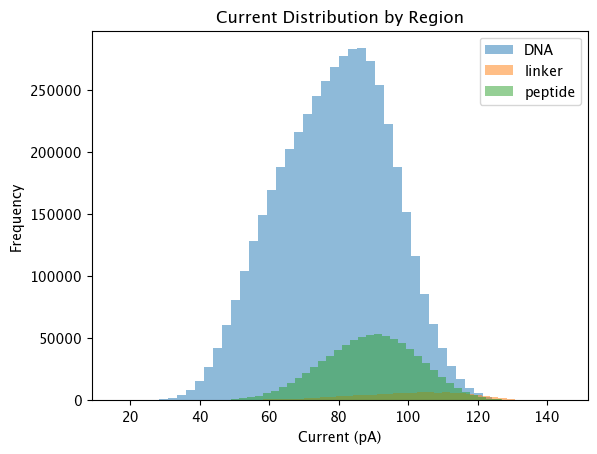

In [5]:
for region in ['DNA', 'linker', 'peptide']:
    subset = db[db['region'] == region]['current_pA']
    plt.hist(subset, bins=50, alpha=0.5, label=region)
    plt.xlabel('Current (pA)')
    plt.ylabel('Frequency')
    plt.title('Current Distribution by Region')
plt.legend()
plt.show()

## **Run HMM: store parameters and compute emission probabilities**

In [6]:
from hmmlearn.hmm import GaussianHMM

# REGION_TO_STATE = {'DNA': 0, 'linker': 1, 'peptide': 2}
# STATE_TO_REGION = {0: 'DNA', 1: 'linker', 2: 'peptide'}

REGION_TO_STATE = {'DNA': 0, 'linker': 1, 'peptide': 1}
STATE_TO_REGION = {0: 'DNA', 1: 'non-DNA'}



means_arr  = np.array(means).reshape(2, 1)
covars_arr = np.array(stds).reshape(2, 1, 1) ** 2

model = GaussianHMM(n_components=2, covariance_type='full', n_iter=0)
model.n_features  = 1               # must be set before covars_ in this hmmlearn version
model.startprob_  = startprob.astype(float)
model.transmat_   = transmat
model.means_      = means_arr
model.covars_     = covars_arr

print("means_   (pA) :", model.means_.flatten())
print("covars_  (pA²):", model.covars_.flatten())
print("startprob     :", model.startprob_)
print("transmat      :\n", model.transmat_)

means_   (pA) : [78.77029498 90.56880372]
covars_  (pA²): [259.2014278  211.70262808]
startprob     : [1. 0.]
transmat      :
 [[9.999e-01 1.000e-04]
 [0.000e+00 1.000e+00]]


## **Run Viterbi to Find the Max Probability**

In [7]:
accuracies  = {}
predictions = {}

for tid in test_db['trace_id'].unique():
    trace = test_db[test_db['trace_id'] == tid]
    X = trace['current_pA'].values.reshape(-1, 1)

    pred_states = model.predict(X)
    true_states = trace['region'].map(REGION_TO_STATE).values

    acc = np.mean(pred_states == true_states)
    accuracies[tid]  = acc
    predictions[tid] = {
        'time_ms':     trace['time_ms'].values,
        'current_pA':  trace['current_pA'].values,
        'true_states': true_states,
        'pred_states': pred_states,
    }

overall_acc = np.mean(list(accuracies.values()))
print(f"Overall accuracy: {overall_acc:.2%}\n")
print(f"{'Trace':>6}  {'Accuracy':>8}")
for tid, acc in sorted(accuracies.items()):
    print(f"  {tid:>6}  {acc:>8.2%}")

Overall accuracy: 92.64%

 Trace  Accuracy
     500    98.09%
     501    98.31%
     502    98.50%
     503    99.34%
     504    98.35%
     505    88.02%
     506    99.44%
     507    89.64%
     508    99.12%
     509    14.98%
     510    66.63%
     511    89.75%
     512    95.17%
     513    98.60%
     514    84.67%
     515    99.49%
     516    86.62%
     517    99.02%
     518    99.67%
     519    93.79%
     520    95.08%
     521    92.96%
     522    99.46%
     523    98.91%
     524    99.74%
     525    95.19%
     526    99.35%
     527    96.12%
     528    74.90%
     529    99.15%
     530    91.32%
     531    99.40%
     532    99.31%
     533    98.21%
     534    95.77%
     535    99.57%
     536    99.45%
     537    98.86%
     538    99.19%
     539    99.28%
     540    78.86%
     541    95.93%
     542    71.20%
     543    99.82%
     544    99.73%
     545    87.73%
     546    99.16%
     547    83.02%
     548    98.91%
     549    93.45%
     55

In [12]:
for tid, acc in sorted(accuracies.items()):
    if acc < 0.9:
        print(f"\nTrace {tid} - Accuracy: {acc:.2%}")


Trace 505 - Accuracy: 88.02%

Trace 507 - Accuracy: 89.64%

Trace 509 - Accuracy: 14.98%

Trace 510 - Accuracy: 66.63%

Trace 511 - Accuracy: 89.75%

Trace 514 - Accuracy: 84.67%

Trace 516 - Accuracy: 86.62%

Trace 528 - Accuracy: 74.90%

Trace 540 - Accuracy: 78.86%

Trace 542 - Accuracy: 71.20%

Trace 545 - Accuracy: 87.73%

Trace 547 - Accuracy: 83.02%

Trace 554 - Accuracy: 49.47%

Trace 555 - Accuracy: 83.15%

Trace 557 - Accuracy: 84.71%

Trace 559 - Accuracy: 71.02%

Trace 563 - Accuracy: 44.96%

Trace 564 - Accuracy: 87.25%

Trace 568 - Accuracy: 86.75%

Trace 574 - Accuracy: 60.20%

Trace 578 - Accuracy: 85.32%

Trace 585 - Accuracy: 74.57%

Trace 593 - Accuracy: 84.71%


## **Visualize**

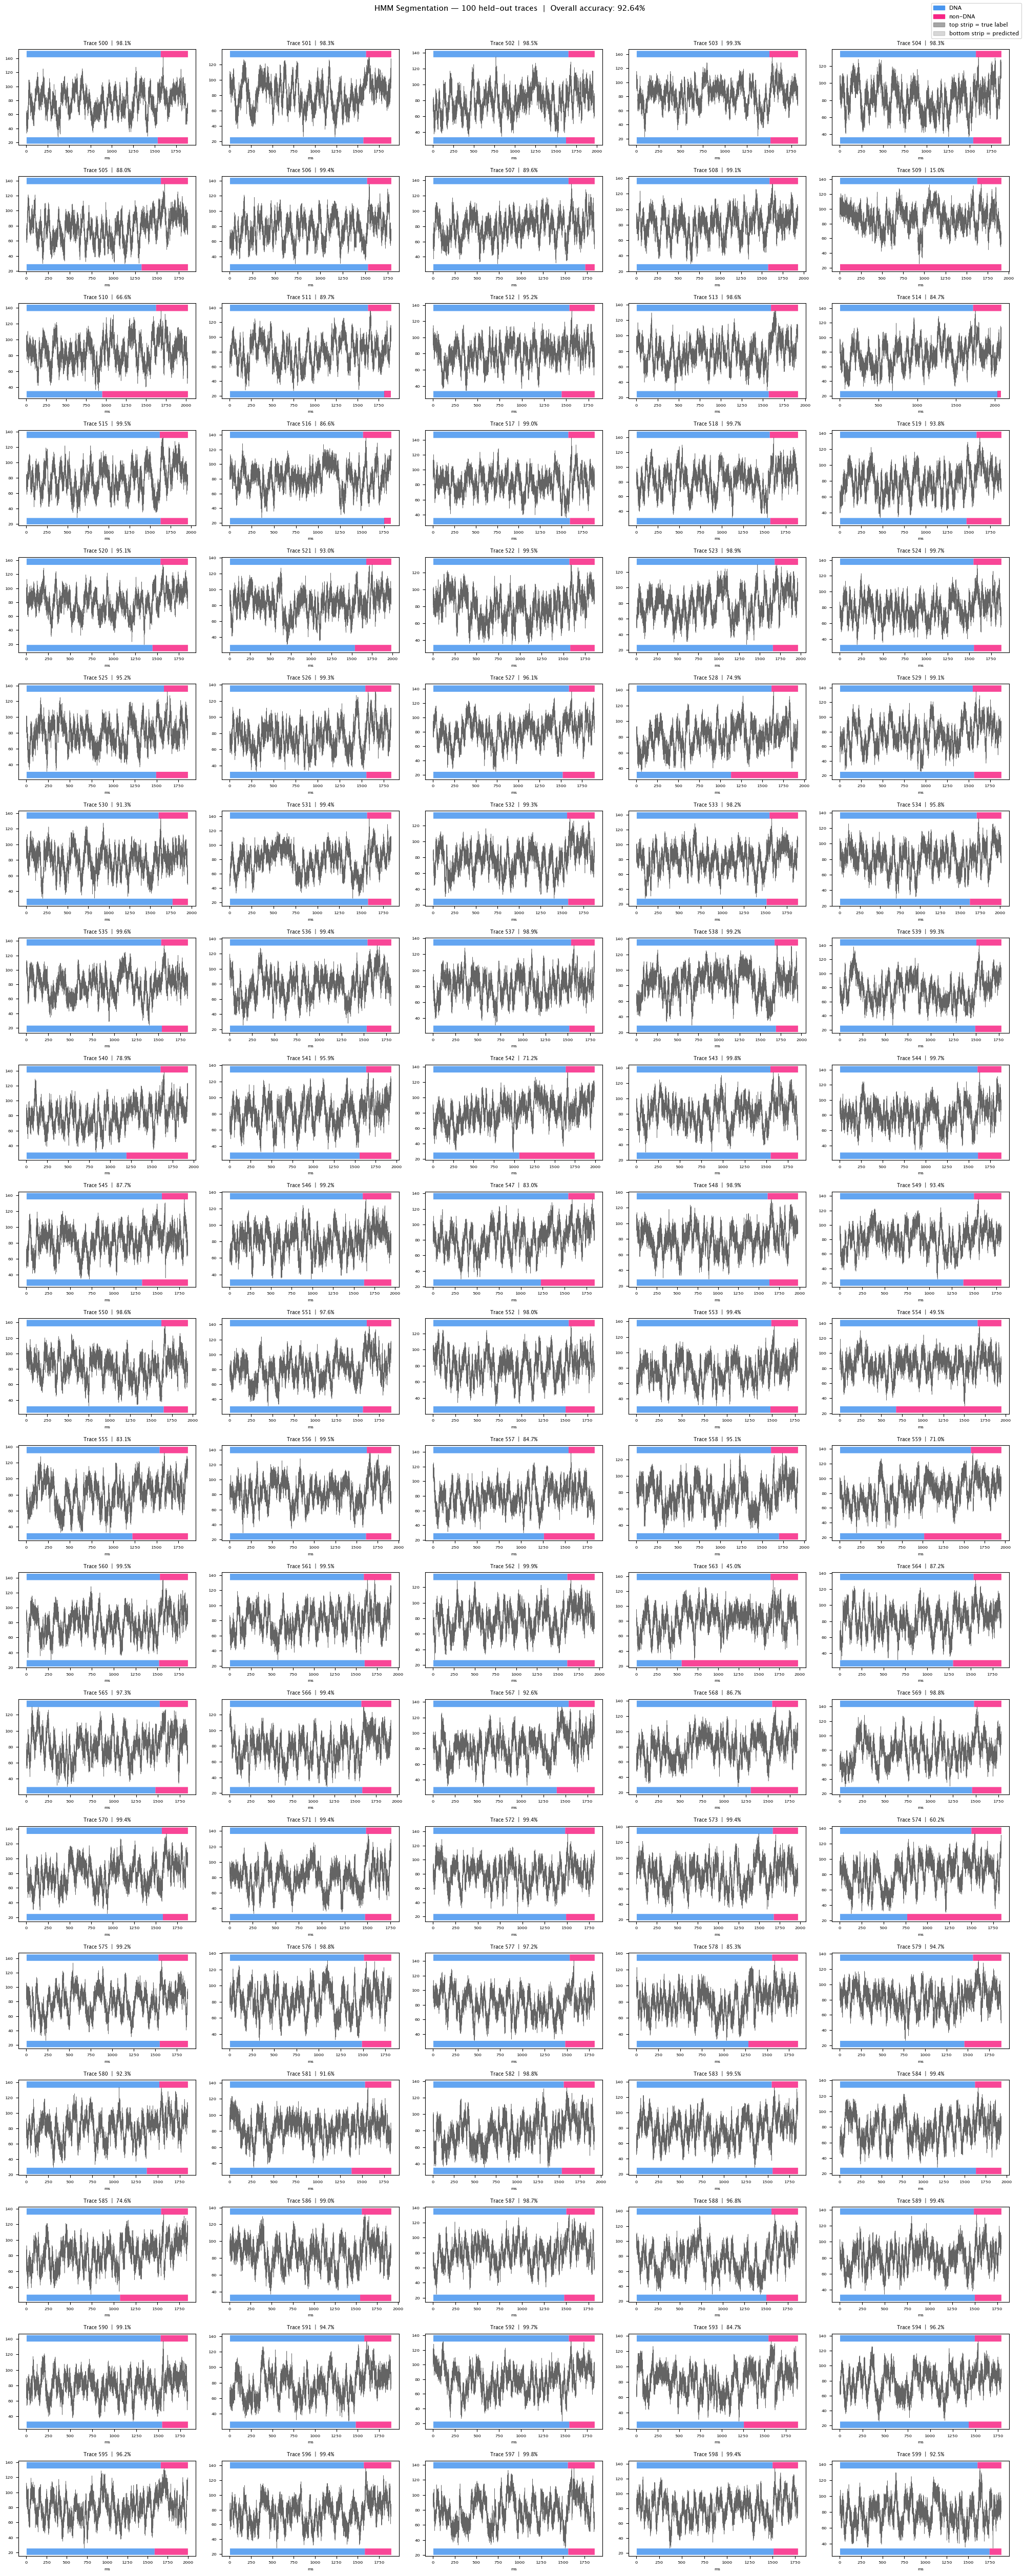

In [8]:
import matplotlib.patches as mpatches

REGION_COLORS = {'DNA': '#4895ef', 'non-DNA': '#f72585'}

def shade_regions(ax, t, states, ylo, yhi, alpha=0.85):
    for state, region in STATE_TO_REGION.items():
        mask = states == state
        if mask.any():
            ax.fill_between(t, ylo, yhi, where=mask,
                            color=REGION_COLORS[region], alpha=alpha, linewidth=0)

n     = len(predictions)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 2.5), squeeze=False)

for idx, (tid, data) in enumerate(predictions.items()):
    ax = axes[idx // ncols][idx % ncols]
    t, I = data['time_ms'], data['current_pA']

    ymin, ymax = I.min(), I.max()
    band = (ymax - ymin) * 0.08

    shade_regions(ax, t, data['true_states'], ymax,        ymax + band)  # top strip = true
    shade_regions(ax, t, data['pred_states'], ymin - band, ymin)          # bottom strip = predicted

    ax.plot(t, I, color='#222', lw=0.4, alpha=0.7)
    ax.set_ylim(ymin - band * 1.2, ymax + band * 1.2)
    ax.set_title(f'Trace {tid}  |  {accuracies[tid]:.1%}', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlabel('ms', fontsize=6)

for idx in range(n, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

legend_patches  = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
legend_patches += [
    mpatches.Patch(color='gray', alpha=0.7, label='top strip = true label'),
    mpatches.Patch(color='gray', alpha=0.3, label='bottom strip = predicted'),
]
fig.legend(handles=legend_patches, loc='upper right', fontsize=8)
fig.suptitle(f'HMM Segmentation — {n} held-out traces  |  Overall accuracy: {overall_acc:.2%}',
             fontsize=11, y=1.005)
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display

trace_ids = list(predictions.keys())

def plot_trace(idx):
    tid = trace_ids[idx]
    data = predictions[tid]
    t, I = data['time_ms'], data['current_pA']

    fig, ax = plt.subplots(figsize=(12, 3))

    shade_regions(ax, t, data['true_states'],  244, 250)   # top
    shade_regions(ax, t, data['pred_states'],  0,   6)     # bottom

    ax.plot(t, I, color='#222', lw=0.4, alpha=0.7)
    ax.set_ylim(0, 250)
    ax.set_title(f'Trace {tid}  |  Accuracy: {accuracies[tid]:.1%}', fontsize=10)
    ax.set_xlabel('ms')

    legend_patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
    legend_patches += [
        mpatches.Patch(color='gray', alpha=0.7, label='top = true'),
        mpatches.Patch(color='gray', alpha=0.3, label='bottom = predicted'),
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()

widgets.interact(plot_trace, idx=widgets.IntSlider(min=0, max=len(trace_ids)-1, step=1, description='Trace'));


interactive(children=(IntSlider(value=0, description='Trace', max=99), Output()), _dom_classes=('widget-intera…

Mean boundary error : -21.728 ms
Std  boundary error : 12.006 ms
MAE                 : 21.728 ms
Max early           : -63.200 ms
Max late            : -6.600 ms


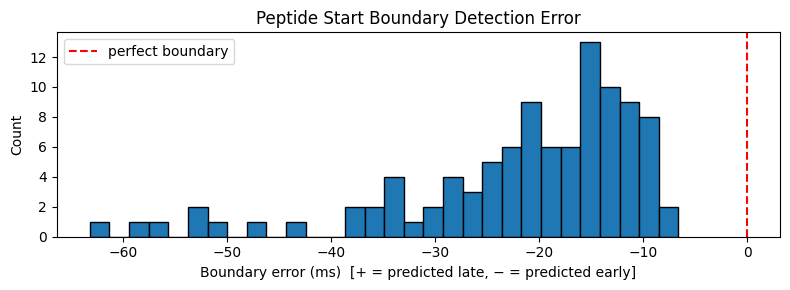

In [11]:
PEPTIDE_STATE = REGION_TO_STATE['peptide']

boundary_errors = {}

for tid, data in predictions.items():
    true_idxs = np.where(data['true_states'] == PEPTIDE_STATE)[0]
    pred_idxs = np.where(data['pred_states'] == PEPTIDE_STATE)[0]

    if len(true_idxs) == 0 or len(pred_idxs) == 0:
        continue  # peptide not found in true or predicted

    true_start_ms = data['time_ms'][true_idxs[0]]
    pred_start_ms = data['time_ms'][pred_idxs[0]]
    boundary_errors[tid] = pred_start_ms - true_start_ms  # positive = predicted late, negative = predicted early

errors = np.array(list(boundary_errors.values()))
print(f"Mean boundary error : {errors.mean():.3f} ms")
print(f"Std  boundary error : {errors.std():.3f} ms")
print(f"MAE                 : {np.abs(errors).mean():.3f} ms")
print(f"Max early           : {errors.min():.3f} ms")
print(f"Max late            : {errors.max():.3f} ms")

plt.figure(figsize=(8, 3))
plt.hist(errors, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='perfect boundary')
plt.xlabel('Boundary error (ms)  [+ = predicted late, − = predicted early]')
plt.ylabel('Count')
plt.title('Peptide Start Boundary Detection Error')
plt.legend()
plt.tight_layout()
plt.show()


## Test on Real Fast5 Data

In [39]:
import pathlib
import tomllib
import poreflow as pf

with open("parameters.toml", "rb") as f:
    config = tomllib.load(f)

input_cfg = config["input"]
data_path = pathlib.Path(input_cfg["path"]) / input_cfg["file"]
target_sfreq = input_cfg["target_SamplingRate"]

CHANNEL = 18   # change to your channel of interest
EVENT_IDX = 20  # index into events found in this channel

with pf.File(data_path) as f:
    raw = f.get_raw(CHANNEL, downsample=target_sfreq)

events = raw.find_events(**config["event_finding"])
if events is None or len(events) == 0:
    raise RuntimeError(f"No events found in channel {CHANNEL}")
events = events.filter_by_duration()
print(f"Found {len(events)} events in channel {CHANNEL}")

ev = events.iloc[EVENT_IDX]
event_current = raw['i'].values[int(ev['start_idx']):int(ev['end_idx'])]
event_ios     = float(ev['ios'])

print(f"Event {EVENT_IDX}: {len(event_current)} samples | IOS = {event_ios:.1f} pA")
print(f"Current range: {event_current.min():.1f} – {event_current.max():.1f} pA")

Found 152 events in channel 18
Event 20: 8031 samples | IOS = 256.3 pA
Current range: 8.7 – 248.3 pA


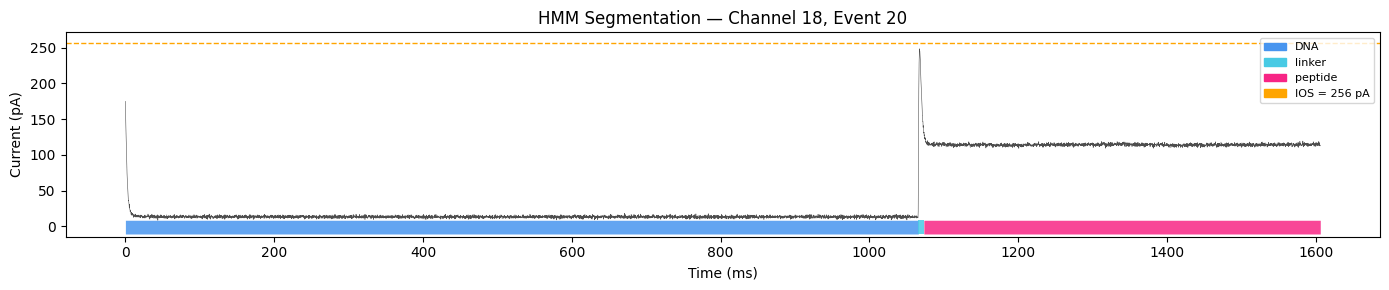

Predicted region fractions:
       DNA: 66.4%
    linker: 0.4%
   peptide: 33.2%


In [17]:
t_ms = np.arange(len(event_current)) * (1000 / target_sfreq)

X = event_current.reshape(-1, 1)
pred_states = model.predict(X)

fig, ax = plt.subplots(figsize=(14, 3))
ymin, ymax = event_current.min(), event_current.max()
band = (ymax - ymin) * 0.08

shade_regions(ax, t_ms, pred_states, ymin - band, ymin)
ax.plot(t_ms, event_current, color='#222', lw=0.4, alpha=0.8)
ax.axhline(event_ios, color='orange', linestyle='--', lw=1, label=f'IOS = {event_ios:.0f} pA')

ax.set_ylim(ymin - band * 1.2, ymax + band * 1.2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Current (pA)')
ax.set_title(f'HMM Segmentation — Channel {CHANNEL}, Event {EVENT_IDX}')

legend_patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
legend_patches.append(mpatches.Patch(color='orange', label=f'IOS = {event_ios:.0f} pA'))
ax.legend(handles=legend_patches, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

print("Predicted region fractions:")
for state, region in STATE_TO_REGION.items():
    print(f"  {region:>8}: {np.mean(pred_states == state):.1%}")

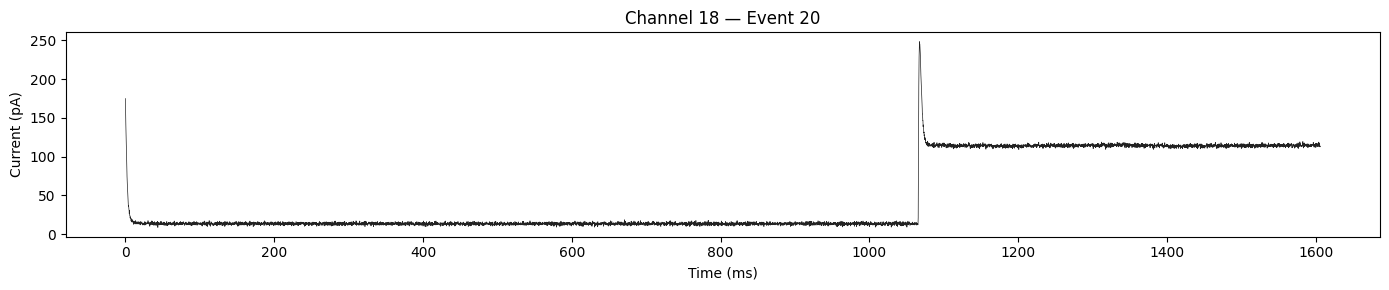

In [18]:
t_ms = np.arange(len(event_current)) * (1000 / target_sfreq)

plt.figure(figsize=(14, 3))
plt.plot(t_ms, event_current, lw=0.5, color='#222')
plt.xlabel('Time (ms)')
plt.ylabel('Current (pA)')
plt.title(f'Channel {CHANNEL} — Event {EVENT_IDX}')
plt.tight_layout()
plt.show()

In [22]:
print(f"Current range: {event_current.min():.1f} – {event_current.max():.1f} pA")
print(f"Event duration: {len(event_current) / target_sfreq:.2f} s")
print(f"IOS: {event_ios:.1f} pA")

Current range: 8.7 – 248.3 pA
Event duration: 1.61 s
IOS: 256.3 pA
